# Homework 2: Probability Models

BEE 4850/5850

**Name**: Emma Thoma

**ID**: mt932

> **Due Date**
>
> Friday, 2/20/26, 9:00pm

Note: I worked with Luca Katzen and used AI for troubleshooting and code syntax.

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit some linear regressions to Chicago
    mortality data.
-   Problem 2 asks you to analyze the probability of Cayuga Lake
    freezing using a logistic regression model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 asks you to look at the impact of the gender of hurricane
    names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()
Pkg.add("LaTeXStrings")
Pkg.add("CSVFiles")

  Activating project at `~/Documents/02 Studium/04_Cornell/01_Classes/BEE4850_Env_Data_Analysis_and_Sim/Homework/hw02-emma-t932`
   Resolving package versions...
  No Changes to `~/Documents/02 Studium/04_Cornell/01_Classes/BEE4850_Env_Data_Analysis_and_Sim/Homework/hw02-emma-t932/Project.toml`
  No Changes to `~/Documents/02 Studium/04_Cornell/01_Classes/BEE4850_Env_Data_Analysis_and_Sim/Homework/hw02-emma-t932/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Documents/02 Studium/04_Cornell/01_Classes/BEE4850_Env_Data_Analysis_and_Sim/Homework/hw02-emma-t932/Project.toml`
  No Changes to `~/Documents/02 Studium/04_Cornell/01_Classes/BEE4850_Env_Data_Analysis_and_Sim/Homework/hw02-emma-t932/Manifest.toml`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using CSVFiles
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using LaTeXStrings # latex formatting for plot strings

## Problems

### Problem 1 (6 points)

Let’s revisit the `chicago` dataset from HW1 (found in
`data/chicago.csv`). We will look at the relationship of the potential
predictor variables `pm25median` (the median density of smaller
pollutant particles), `o3median` (the median concentration of O$_3$),
`so2median` (the median concentration of SO$_2$), and `tmpd` (mean daily
temperature) with the variable we would like to predict, `death` (the
number of non-accidental deaths on that day).

#### Problem 1.1

Plot each predictor variable against the response variable (make sure to
include labels and titles for each plot). Describe what you observe
about the bivariate relationships, if one exists (*e.g.* does it look
like they exist, are they linear, positive/negative, etc.) Does a linear
regression seem appropriate from any of these plots? Which predictor do
you think is most appropriate for a linear regression model and why?


In [3]:
data_chicago = DataFrame(load("data/chicago.csv")) # load data into DataFrame
chicago_summary = DataFrame(
    category = String[],
    min=Float64[],
    q25=Float64[],
    median=Float64[],
    q75=Float64[],
    max=Float64[],
    mean=Float64[],
    nas=Int[]
)
for colname in names(data_chicago)[2:end]
    col = data_chicago[!, colname]
    push!(chicago_summary, [
    colname,
    minimum(skipmissing(col)),
    quantile(skipmissing(col), 0.25),
    median(skipmissing(col)),
    quantile(skipmissing(col), 0.75),
    maximum(skipmissing(col)),
    mean(skipmissing(col)),
    count(ismissing, col)
    ])
end


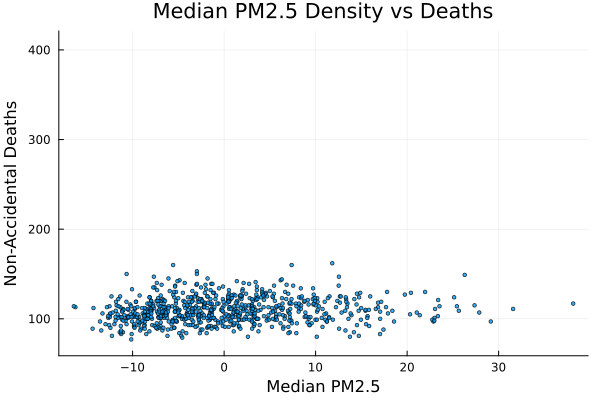

In [4]:
# scatterplot of deaths vs. pm25.
scatter(
    data_chicago.pm25median, data_chicago.death,
    xlabel="Median PM2.5",
    ylabel="Non-Accidental Deaths",
    markersize=2,
    alpha=0.8,
    legend=false,
    title="Median PM2.5 Density vs Deaths")

Over the full range of PM2.5 concentrations, most death counts fall between 50 and 150. There is a possible upward trend at PM2.5 concentrations above 20, where deaths appear to exceed 100, however the number of observations in this range is limited, making it difficult to draw any firm conclusions about a relationship between PM2.5 and mortality.

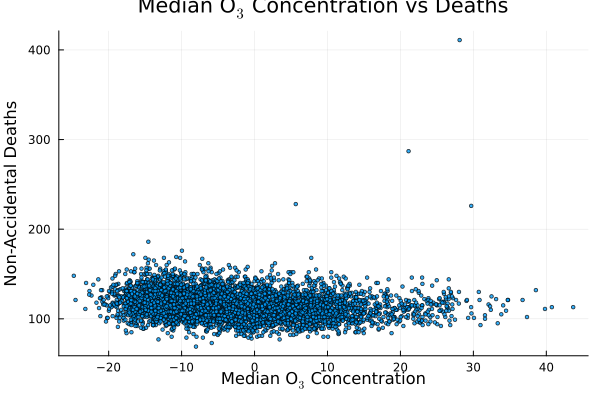

In [5]:
# scatterplot of deaths vs. o3.
scatter(
    data_chicago.o3median, data_chicago.death,
    xlabel=L"Median O$_3$ Concentration",
    ylabel="Non-Accidental Deaths",
    markersize=2,
    alpha=0.8,
    legend=false,
    title=L"Median O$_3$ Concentration vs Deaths")

Deaths are centered around approximately 110, with most values ranging from 60 to 150. There are four outliers at O3 concentrations between 20 and 30, where deaths exceed 200, with one observation exceeding 400, but no clear pattern is revealed.

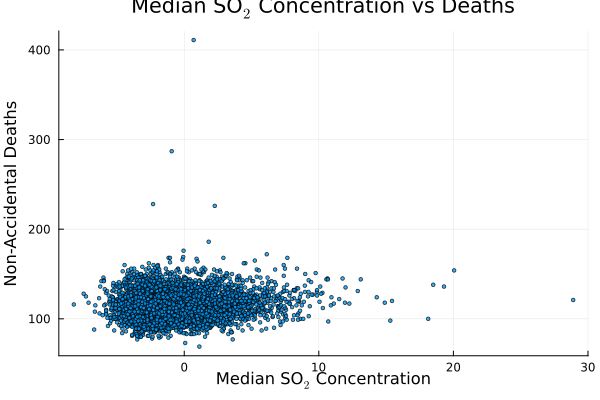

In [6]:
# scatterplot of deaths vs. SO2.
scatter(
    data_chicago.so2median, data_chicago.death,
    xlabel=L"Median SO$_2$ Concentration",
    ylabel="Non-Accidental Deaths",
    markersize=2,
    alpha=0.8,
    legend=false,
    title=L"Median SO$_2$ Concentration vs Deaths")

The plot of SO₂ concentration against deaths shows no clear pattern or relationship between the two variables.

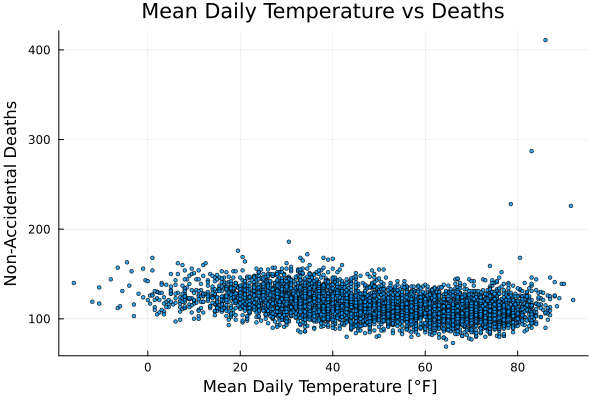

In [7]:
# scatterplot of deaths vs. temp.
scatter(
    data_chicago.tmpd, data_chicago.death,
    xlabel="Mean Daily Temperature [°F] ",
    ylabel="Non-Accidental Deaths",
    markersize=2,
    alpha=0.8,
    legend=false,
    title="Mean Daily Temperature vs Deaths")

There are some notable spikes for very high tempertures, but apart from that there could be a slight negative trend in death rates as the temperature decreases.

The trend is not completley clear and could also be due to noise but compared to the other plots, this one is still the most promising and worth investigating further.


#### Problem 1.2

You decide to focus on the relationship between `tmpd` and `death`. Your
classmate suggests that you use a Gaussian-error linear regression
model. Based on this suggestion, calculate the regression coefficients
and error variance. Explain the interpretation of the coefficients that
you obtain **in this specific problem context**.


In [8]:
# Gaussian-error linear regression model
# Y = beta0 + beta1*X + e
data_chicago_clean = dropmissing(data_chicago, [:tmpd, :death])

X = data_chicago_clean.tmpd
Y = data_chicago_clean.death

b = zeros(2)
b[2] = cov(X, Y) / var(X)
b[1] = mean(Y) - b[2] * mean(X)

e = Y - [ones(length(X)) X] * b # residuals
s2 = (e' * e) / (nrow(data_chicago) - 2) #error variance

println("β0, β1 = ", b)
println("s^2 = ", s2)


β0, β1 = [129.95705121476823, -0.28964429615009885]
s^2 = 202.31531425938178


**Interpretation of coefficients.**
- Intercept beta0: The intercept with the y-axis for our regression model. In this case the number of deaths we expect to see at 0°F.
- Slope beta1: The slope of our linear regression model. In this case the slope is -0.29. This means if the temperature differs by +1, we expect to see a decrease in deaths of -0.29.
- e (Residuals): Differences in observed vs predicted values.
- s2 (Error variance): The average squared residual, corrected for the two estimated coefficients. Squaring prevents positive and negative residuals from cancelling out. In this case s2 is approximately 202, and taking the square root gives a residual standard error of approximately 14 deaths, meaning our model's predictions are off by about 14 deaths per day on average.


#### Problem 1.3

Add your fitted regression line and a 90% prediction interval to your
scatterplot of `tmpd` and `death`. Using this and any other diagnostics,
do you agree with the Gaussian-error linear model assumption? Why or why
not?


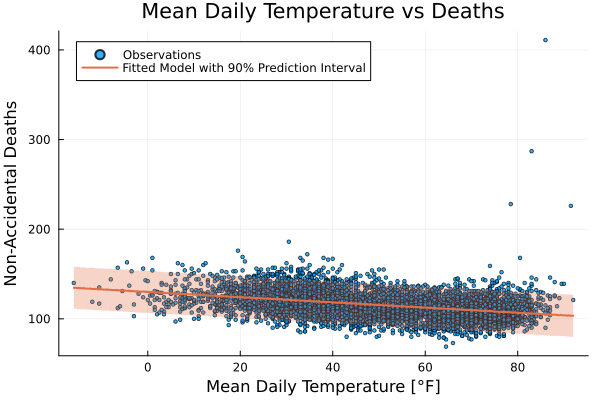

In [9]:
# simulate 10,000 predictions
x = minimum(X):0.1:maximum(X)
mu = b[1] .+ b[2] .* x
y_sim = zeros(length(x), 10_000)
for i = 1:length(x)
    y_sim[i, :] = rand(Normal(mu[i], sqrt(s2)), 10_000)
end

# take quantiles to find 90% prediction interval
y_q = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_sim; dims=2)

scatter(
    X, Y,
    xlabel="Mean Daily Temperature [°F]",
    ylabel="Non-Accidental Deaths",
    markersize=2,
    alpha=0.8,
    label="Observations",
    title="Mean Daily Temperature vs Deaths"
)

plot!(x,
    y_q[:, 2],
    ribbon=(y_q[:, 2] - y_q[:, 1], y_q[:, 3] - y_q[:, 2]),
    linewidth=2,
    fillalpha=0.3,
    label="Fitted Model with 90% Prediction Interval"
)

This regression model seems to work for most of the data, but considering the data for very high temperatures (>70°F), outliers far exceed the 90% prediction interval, indicating that the model will not make reliable predictions for these high temperature values.



### Problem 2 (6 points)

This problem is adapted from Example 4.1 and 4.2 in Daniel Wilks’
*Statistical Methods in the Atmospheric Sciences*. Updating the table in
that book, Cayuga Lake has frozen in 1796, 1816, 1856, 1875, 1884, 1904,
1912, 1934, 1961, 1979, and 2015[1]. The probability of whether a severe
enough cold spell to freeze the lake occurs is related to changes in
global mean temperature. The file `data/HadCRUT5.1Analysis_gl.txt`
contains estimates of monthly global mean temperature anomalies (in
$^\circ$ C, relative to the 1961–1990 mean) as well as the annual global
temperature anomaly. You would like to build a model to predict the
probability that Cayuga Lake freezes based on the winter (DJF)
temperature anomaly.

#### Problem 2.1

Write down a logistic regression model for the probability that Cayuga
Lake freezes in a given winter. Encode the occurrence of freezing as a
1, and non-freezing as 0. Load the temperature data and fit this model.
The format of the data file is a little awkward, as the even rows are
the number of stations (which should be ignored) and have uneven number
of space delimiters. The first 13 columns are the year and the monthly
means; the final column is the annual average (which we don’t want to
use). Another complication is that the (even-numbered) station rows
don’t have an entry in the 14th column. In Julia, you can load the file
with

``` julia
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ", 
    ignorerepeated=true, header=false, 
    silencewarnings=true, DataFrame) 
```

To simplify the analysis, since we don’t always know whether the lake
froze in the January starting a year or the December ending a year,
let’s assume that the years in which the lake froze correspond to the
winter starting the year (so the DJF mean corresponding to the freezing
in 1884 would include the December from 1883 and the January and
February from 1884). You will only be able to use freezing events
between 1851 and the present day due to the temperature data. Interpret
the coefficients from your model fit **in this specific problem
context**.


In [10]:
temp_dat = CSV.read("data/HadCRUT5.1Analysis_gl.txt", delim=" ",
ignorerepeated=true, header=false,
silencewarnings=true, DataFrame)

# data frames with odd rows only
temp_dat_odd = temp_dat[1:2:end, :]

#new DataFrame with DFJ anomaly for each winter
temp_dat_org = DataFrame(
    year = Int64[],
    djf_anom = Float64[],
    frozen = Int64[] #1=true (frozen), 0=false
)

# store frozen years manually
f = [1856, 1875, 1884, 1904, 1912, 1934, 1961, 1979, 2015] #store data after 1851

# fill DataFrame
for i in 2:nrow(temp_dat_odd)
    row = temp_dat_odd[i, :]
    row_prev = temp_dat_odd[i-1, :] #previous year
    year = row[:Column1]
    dec = row_prev[:Column13]
    jan = row[:Column2]
    feb = row[:Column3]
    djf_anom = mean([dec, jan, feb])
    if year in f
        frozen = 1
    else
        frozen = 0
    end
    push!(temp_dat_org, [year, djf_anom, frozen])
end

# code adapted from slides
invlogit(x) = exp(x) / (1 + exp(x)) #convert into number between 0 and 1

function log_lik(params, y, x) # log-likelihood function
    b0, b1 = params                          # parameters we want to find
    p = invlogit.(b0 .+ b1 .* x)            # predicted probabilities for each year
    ll = sum(logpdf.(Bernoulli.(p), y))      # log-likelihood
    return ll
end

# maximize log-likelihood
lb = [-10.0, -10.0]
ub = [10.0, 10.0]
p0 = [0.0, 0.0]

optim_out = Optim.optimize(p -> -log_lik(p, temp_dat_org.frozen, temp_dat_org.djf_anom), lb, ub, p0) #maximise by minamizing neg log-lik
mle = round.(optim_out.minimizer; digits=2) # maximum likelihood estimates

println("Logistic regression model:")
println("p(freeze) = invlogit(β0 + β1 * DJF_anomaly)")
println("β0 = ", mle[1])
println("β1 = ", mle[2])


Logistic regression model:
p(freeze) = invlogit(β0 + β1 * DJF_anomaly)
β0 = -3.02
β1 = -0.71



#### Problem 2.2

Plot the modeled probability of freezing as a function of the DFJ
temperature anomaly, and how this probability has changed over time.
Does this model seem reasonable? How might you determine this?


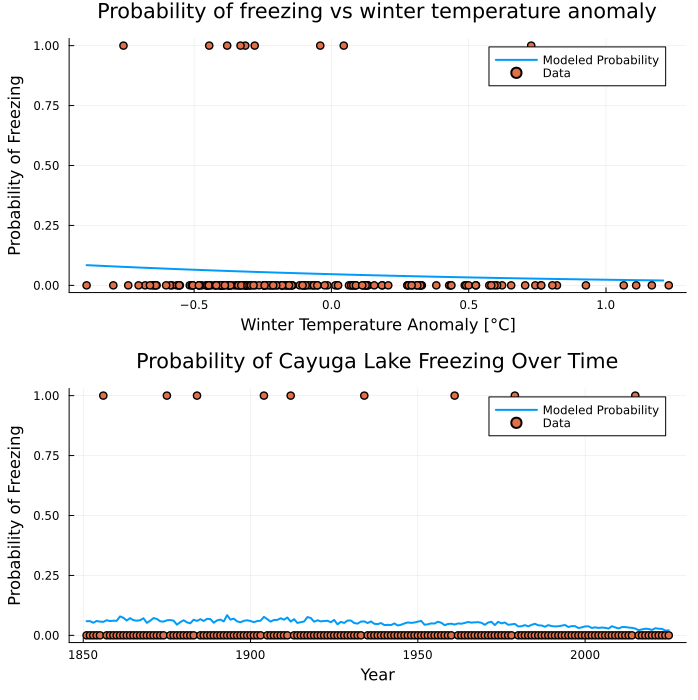

In [11]:
# Probability of freezing vs DFJ temp anomaly
x_pred = minimum(temp_dat_org.djf_anom):0.1:maximum(temp_dat_org.djf_anom)
p_pred = invlogit.(mle[1].+mle[2]*x_pred)
p1 = plot(x_pred, p_pred,
    linewidth=2,
    label="Modeled Probability",
    xlabel="Winter Temperature Anomaly [°C]",
    ylabel="Probability of Freezing",
    title="Probability of freezing vs winter temperature anomaly"
)
scatter!(
    temp_dat_org.djf_anom, temp_dat_org.frozen,
    label="Data"
)
# Probability over time
p2 = plot(
    temp_dat_org.year, invlogit.(mle[1] .+ mle[2] .* temp_dat_org.djf_anom),
    linewidth=2,
    label="Modeled Probability",
    xlabel="Year",
    ylabel="Probability of Freezing",
    title="Probability of Cayuga Lake Freezing Over Time"
)
scatter!(
    temp_dat_org.year, temp_dat_org.frozen,
    label="Data"
)

plot(p1, p2, layout=(2,1), size=(700,700))


In [12]:
p_fit = invlogit.(mle[1] .+ mle[2] * temp_dat_org.djf_anom)
total_pred = round(sum(p_fit); digits=0) #Sum of probabilites --> Years with predicted freezing according to Modeled
total_obs = length(f)
@show (total_pred, total_obs)

(total_pred, total_obs) = (9.0, 9)


(9.0, 9)

The downward trend in predicted freezing probability over time is consistent with rising global temperatures, and the negative relationship between freezing probability and winter temperature anomaly is physically reasonable, supporting the plausibility of the model.
The model correctly predicts the total number of freezing events when summing all predicted probabilities. However, this is just one diagnostic and does not tell us whether the model assigns high probabilities to the correct years. From the plot, the predicted probability decreases with increasing temperature anomaly, which is physically reasonable. However, the maximum predicted probability never exceeds approximately 12.5%, even for the coldest winters on record. This means the model would never confidently predict a freezing event for any individual year, which is a significant limitation. This is likely a consequence of freezing being a very rare event, with only 9 freeze events out of roughly 170 years, the model is heavily biased towards predicting "no freeze" and struggles to assign high probabilities to the years the lake actually froze.


#### Problem 2.3

What winter temperature anomaly would be required for less than a 1%
probability of Cayuga Lake freezing?


In [13]:
b0 = mle[1]
b1 = mle[2]

# solve for x
p_target = 0.01
x = ((log(p_target/(1-p_target))-b0)/b1)
@show round(x,digits=1);

round(x, digits = 1) = 2.2


A winter anomaly of more than 2.2°C would be required for a less than 1% probability of Cayuga lake freezing.


### Problem 3 (6 points)

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

#### Problem 3.1

Write down and fit a Poisson regression model for salamander counts
using the percentage of ground cover as a predictor. You may need to
standardize the predictors as they are much larger than the counts,
which you can do using the following function (or its equivalent):

[1] Many of these dates, particularly prior to the 20th century, are
subject to some debate, and would be different depending on the data
source. Nevertheless, let’s use this dataset.

In [14]:
stdz(x) = (x .- mean(x)) / std(x)

stdz (generic function with 1 method)

In [15]:
dat_sal = DataFrame(CSV.File("data/salamanders.csv"));
# @show dat_sal;

In [16]:
# pctcover as predictor to predict salaman
cover_stdz = stdz(dat_sal.PCTCOVER)
sal_count = dat_sal.SALAMAN

function sal_loglik(params, x, y)
    b0, b1 = params
    λ = exp.(b0 .+ b1 .* x)
    loglik = sum(logpdf.(Poisson.(λ), y))
end
# fit model
init = [0.0, 0.0]
optim_out = optimize(b -> -sal_loglik(b, cover_stdz, sal_count), init, BFGS()) #poisson is convex, only one maximum
mle = optim_out.minimizer

println("β0 = ", round(mle[1], digits=2))
println("β1= ", round(mle[2],digits= 2))

β0 = 0.43
β1= 1.16


**beta0 = 0.43** -> The expected log count when ground cover is at its average (since standardized).

**beta1 = 1.16** -> Slope or change in log expected count for a one standard deviation increase in ground cover. e^(b1) = 3.19, meaning that for one standard deviation increase in ground cover we would expect to count 3.19 times as many salamanders.

#### Problem 3.2

Plot the expected counts and 90% prediction intervals from your model
(based on 1,000 simulations from the model) along with the data. How
well does the model predict the observed counts? In what ways does it do
a good or bad job?


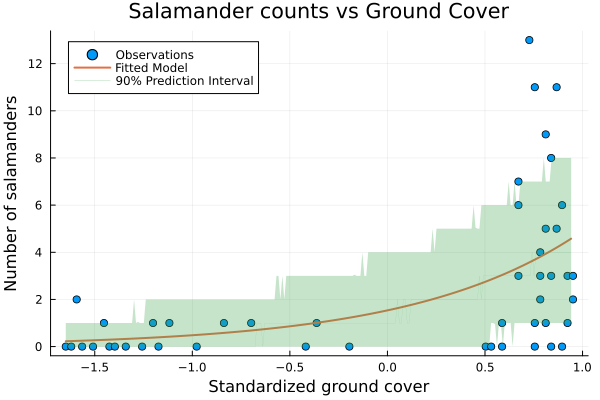

In [17]:
# simulate 1000 times
x_pred = minimum(cover_stdz):0.01:maximum(cover_stdz)
y_sim = zeros(length(x_pred), 1000)

for i in 1:length(x_pred)
    λ_i = exp.(mle[1] .+ mle[2] .* x_pred[i])
    y_sim[i, :] = rand(Poisson(λ_i), 1000)
end

# take quantiles for 90% interval
y_q = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_sim, dims=2)

# plot
scatter(
    cover_stdz, sal_count,
    label="Observations",
    xlabel="Standardized ground cover",
    ylabel="Number of salamanders",
    title="Salamander counts vs Ground Cover"
)
# analytical expected value for the line
plot!(x_pred, exp.(mle[1] .+ mle[2] .* x_pred),
    linewidth=2,
    label="Fitted Model"
)
# simulated quantiles for the ribbon
plot!(x_pred, y_q[:, 2],
    ribbon=(y_q[:, 2] - y_q[:, 1], y_q[:, 3] - y_q[:, 2]),
    linewidth=0,
    fillalpha=0.3,
    label="90% Prediction Interval"
)


The model correctly captures the positive relationship between ground cover and salamander counts, predicting higher counts for higher ground cover percentages. However, between 0.5 and 1.0 standardized ground cover, several observations are two to three times higher than the expected value and exceed the 90% prediction interval. The data is overdispersed, since Poisson assumes variance equals mean. The variability suggests that other factors influence salamander counts, which are not accounted for in this mdoel.


#### Problem 3.3

Can you improve the model by including forest age as a predictor? How
did you determine whether this helps or does not help with prediction?


In [18]:
age_stdz = stdz(dat_sal.FORESTAGE)

function sal_loglik2(params, x1, x2, y)
    b0, b1, b2 = params
    λ = exp.(b0 .+ b1 .* x1 .+ b2 .* x2)  # include x2!
    loglik = sum(logpdf.(Poisson.(λ), y))
end
# fit model
init = [0.0, 0.0, 0.0]
optim_out = optimize(b -> -sal_loglik2(b, cover_stdz, age_stdz, sal_count), init, BFGS()) #poisson is convex, only one maximum
mle2 = optim_out.minimizer
@show round.(mle2; digits=5);

round.(mle2; digits = 5) = [0.42932, 1.16247, -0.00408]


In [19]:
ll1 = sal_loglik(mle, cover_stdz, sal_count)
ll2 = sal_loglik2(mle2, cover_stdz, age_stdz, sal_count)
@show ll1, ll2;

(ll1, ll2) = (-103.18196213053524, -103.18106371242378)


Taking forest age into account slightly increases the log-likelihood from -103.182 to -103.181, which would typically suggest a marginal improvement in model fit. However, the difference is so small that it is negligible and the two-predictor model is not meaningfully better. Forest age therefore does not appear to be a valuable predictor of salamander counts in this dataset.


### Problem 4 (7 points)

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis
(note that this dataset excludes Hurricanes Katrina and Audrey because
they were “outliers”). While we won’t replicate the specific analysis in
this paper, let’s use the data to look at this hypothesis.

#### Problem 4.1

One might interpret the hypothesis to claim that the impact of the name
is strengthened by the the more powerful. A measure of hurricane
strength is its minimum pressure (`min_pressure` in the dataset). Fit a
Poisson regression model that predicts deaths (`deaths`) using the
gender of the name (`female`) and minimum pressure (you may need to
standardize the pressure). We use `female` instead of the continuous
measure of the `femininity` of the name as this is highly subjective and
has some weird coding (such as “Sandy” being coded as one of the most
female names).


In [26]:
# Load data
dat_hur = DataFrame(CSV.File("data/Hurricanes.csv"));

In [21]:
# gender and pressure as predictors
pressure_stdz = stdz(dat_hur.min_pressure)
female = dat_hur.female
deaths = dat_hur.deaths

function hur_loglik(params, x1, x2, y)
    b0, b1, b2 = params
    λ = exp.(b0 .+ b1 .* x1 .+ b2 .* x2)
    loglik = sum(logpdf.(Poisson.(λ), y))
end
# fit model
init = [0.0, 0.0, 0.0]
optim_out = optimize(b -> -hur_loglik(b, pressure_stdz, female, deaths), init, BFGS()) #poisson is convex, only one maximum
mle3 = optim_out.minimizer

# regression model
println("Poisson regression model:")
println("deaths = e^(β0 + β1 * pressure(stdz) + β2 * female)")
println("β0 = ", round(mle3[1], digits=2))
println("β1 = ", round(mle3[2], digits=2))
println("β2 = ", round(mle3[3], digits=2))

Poisson regression model:
deaths = e^(β0 + β1 * pressure(stdz) + β2 * female)
β0 = 2.41
β1 = -0.72
β2 = 0.47


**Interpretation of coefficients**

beta0: The expected log deaths for a male-named hurricane at average pressure. Exponentiating gives the expected death count: exp(2.41) ≈ 11 deaths.

beta1: A one standard deviation increase in minimum pressure multiplies the expected death count by exp(-0.72) ≈ 0.49, meaning deaths are roughly halved as pressure increases (hurricane weakens).

beta2: Female-named hurricanes are associated with exp(0.47) ≈ 1.60 times as many deaths as male-named hurricanes.


#### Problem 4.2

Interpret the results by generating 10,000 counterfactual simulations
for hurricanes with male and female names. Plot the expected values and
90% prediction intervals from these two sets of simulations and compare
with the observed storm deaths. Where does the model do well or not
well?


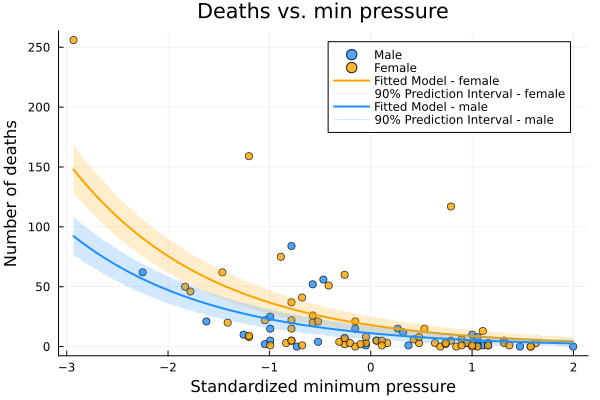

In [50]:
# simulate 10000 times - male
x_pred = minimum(pressure_stdz):0.01:maximum(pressure_stdz)
y_sim_f = zeros(length(x_pred), 10000)
y_sim_m = zeros(length(x_pred), 10000)

# female sim
for i in 1:length(x_pred)
    λ_i = exp.(mle3[1] .+ mle3[2] .* x_pred[i] .+ mle3[3] .*1) #mle[3]*1, because all female
    y_sim_f[i, :] = rand(Poisson(λ_i), 10000)
end

# male sim
for i in 1:length(x_pred)
    λ_i = exp.(mle3[1] .+ mle3[2] .* x_pred[i] .+ mle3[3] .*0)
    y_sim_m[i, :] = rand(Poisson(λ_i), 10000)
end

# take quantiles for 90% interval
y_q_f = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_sim_f, dims=2)
y_q_m = mapslices(v -> quantile(v, [0.05, 0.5, 0.95]), y_sim_m, dims=2)

# plot
scatter(
    pressure_stdz, deaths,
    group=dat_hur.female,
    labels=["Male" "Female"],
    color=["dodgerblue" "orange"],
    xlabel="Standardized minimum pressure",
    ylabel="Number of deaths",
    title="Deaths vs. min pressure",
    alpha=0.8
)
# analytical expected value for the line - female
plot!(x_pred, exp.(mle3[1] .+ mle3[2] .* x_pred .+ mle3[3] .* 1),
    linewidth=2,
    label="Fitted Model - female",
    color="orange"
)
# simulated quantiles for the ribbon
plot!(x_pred, y_q_f[:, 2],
    ribbon=(y_q_f[:, 2] - y_q_f[:, 1], y_q_f[:, 3] - y_q_f[:, 2]),
    linewidth=0,
    fillalpha=0.2,
    label="90% Prediction Interval - female",
    color="orange"
)
# analytical expected value for the line - male
plot!(x_pred, exp.(mle3[1] .+ mle3[2] .* x_pred .+ mle3[3] .* 0),
    linewidth=2,
    label="Fitted Model - male",
    color="dodgerblue"
)
# simulated quantiles for the ribbon
plot!(x_pred, y_q_m[:, 2],
    ribbon=(y_q_m[:, 2] - y_q_m[:, 1], y_q_m[:, 3] - y_q_m[:, 2]),
    linewidth=0,
    fillalpha=0.2,
    label="90% Prediction Interval - male",
    color="dodgerblue"
)

The model captures the relationship of increasing death rates with lower minimum pressure, as expected. As the data is very variable, similar to the salamander counts, the model fails to capture the full spread of observed deaths, with some extreme events falling well outside the 90% prediction interval. Again, the true variance in hurricane deaths is much larger than the Poisson model assumes, driven by factors not included in the model. The fitted model for female-named hurricanes predicts higher death tolls than male-named hurricanes across all pressure values, suggesting some support for the paper's hypothesis.


#### Problem 4.3

Does the gender effect size resulting from this model seem reasonable to
you? Draw on qualitative or quantitative assessments to justify your
assessment of reasonableness.


According to the model, female-named hurricanes have a death rate 1.6 times as high as male-named hurricanes with the same minimum pressure. The underlying hypothesis, that people underestimate the danger of female-named hurricanes, just as society has historically underestimated women, is interesting and not completely unreasonable. However, a 60% increase in deaths attributable solely to the gender of a hurricane's name seems extremely large, and it is hard to imagine that people would change their behaviour so profoundly based on a name alone.

It is more likely that many other factors play a relevant role in hurricane death tolls, such as population density, storm path, and disaster preparedness, which were not accounted for in this model. Additionally, the dataset is relatively small at approximately 90 hurricanes, meaning the observed effect could partly be a result of chance. A more comprehensive model including additional predictors would be needed to draw more confident conclusions about the role of name gender.


#### Problem 4.4

We can now stop taking this hypothesis seriously. To what extent do you
think the finding could be an artifact of the dataset (e.g. there is no
actual effect, but there are coincidental features of the data that
produce the result that female-named storms are more deadly than
male-named storms)? Justify this conclusion with specific reference to
an exploratory analysis of the data.


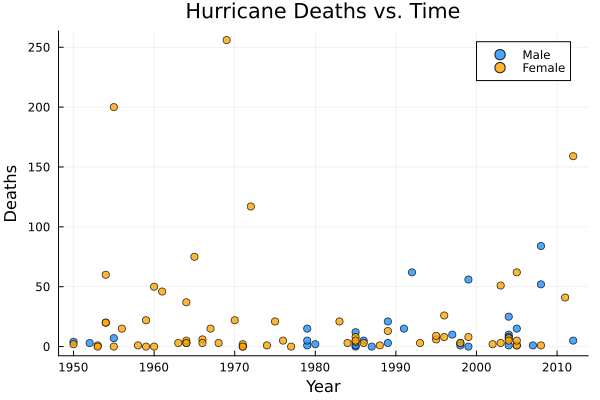

In [51]:
# hurricanes over time
scatter(dat_hur.year, dat_hur.deaths, 
 group=dat_hur.female,
 xlabel="Year",
 ylabel="Deaths",
 title="Hurricane Deaths vs. Time",
 labels=["Male" "Female"],
 color=["dodgerblue" "orange"],
 alpha=0.8)

The plot illustrates that before the 1980s, almost all hurricanes were given female names, and only after that did male names begin to be more common. Older hurricanes occurred in an era with less advanced warning technology, weaker building codes, and less developed disaster preparedness, all of which contributed to higher death tolls independent of the hurricane's name. This could explain much of the observed gender effect in the dataset.

Finally, with only approximately 90 hurricanes in the dataset, a few extreme events can disproportionately influence the results, making it difficult to distinguish a true gender effect from random chance.

In summary, it is very likely that the observed higher death rates are an artifact of the dataset rather than a true causal effect. 


## References

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.